In [1]:
# --- NEW: Force Jupyter to reload modules automatically ---
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('../src'))

from data_loader import download_price_data, clean_price_data, download_fundamentals
from factors import compute_momentum, compute_volatility, compute_roe, compute_cross_sectional_zscore
from signals import build_composite_signal
from optimizer import generate_optimized_weights
from backtest import calculate_portfolio_performance, generate_target_weights

# 1. Load Data
mvp_universe = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
                'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
                'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM']

# --- NEW: Start in 2022 to align with yfinance fundamental data availability ---
prices_raw, _ = download_price_data(mvp_universe, '2022-01-01', '2026-03-31')
prices = clean_price_data(prices_raw)
daily_returns = prices.pct_change(fill_method=None).dropna()
fundamentals = download_fundamentals(prices.columns)

import numpy as np

# 1. Clean the Returns: Replace INFs, and aggressively CLIP extreme outliers
# A daily return > +100% (1.0) or < -90% (-0.9) in mega-caps is a data glitch.
daily_returns = prices.pct_change(fill_method=None)
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan)
daily_returns = daily_returns.clip(lower=-0.90, upper=1.0) # Cap extreme glitches
daily_returns = daily_returns.dropna(how='all')

# 2. Compute Raw Factors
raw_mom = compute_momentum(prices).replace([np.inf, -np.inf], np.nan).dropna(how='all')
raw_vol = compute_volatility(daily_returns).replace([np.inf, -np.inf], np.nan).dropna(how='all')

# Sanitize ROE: Extremely prone to "near-zero" division creating massive floats
raw_roe = compute_roe(fundamentals, prices.index).replace([np.inf, -np.inf], np.nan)
raw_roe = raw_roe.clip(lower=-50, upper=50).dropna(how='all') # Cap ROE between -5000% and +5000%

# 3. Standardize (Z-Scores)
z_mom = compute_cross_sectional_zscore(raw_mom)
z_vol = -compute_cross_sectional_zscore(raw_vol)
z_roe = compute_cross_sectional_zscore(raw_roe)

# 4. Build Signal and do one final sweep for anomalies
composite_scores = build_composite_signal(z_mom, z_vol, z_roe, weights={'mom': 0.4, 'vol': 0.3, 'qual': 0.3})
composite_scores = composite_scores.replace([np.inf, -np.inf], np.nan)

# 5. GENERATE OPTIMIZED WEIGHTS (Max 15% per stock)
optimized_weights = generate_optimized_weights(composite_scores, daily_returns, top_n=20, max_weight=0.15)

2026-03-27 22:08:18,660 - INFO - Downloading data for 30 tickers from 2022-01-01 to 2026-03-31...
2026-03-27 22:08:20,007 - INFO - Shape before cleaning: (1062, 30)
2026-03-27 22:08:20,010 - INFO - Shape after cleaning: (1062, 30) (0 dropped)
2026-03-27 22:08:20,012 - INFO - Fetching fundamentals for 30 tickers...
2026-03-27 22:08:38,258 - INFO - Computing momentum (lookback=252, skip=21)...
2026-03-27 22:08:38,266 - INFO - Computing annualized rolling volatility (window=252)...
2026-03-27 22:08:38,272 - INFO - Computing Quality factor (ROE)...
2026-03-27 22:08:38,292 - INFO - Computing cross-sectional z-scores...
2026-03-27 22:08:38,294 - INFO - Computing cross-sectional z-scores...
2026-03-27 22:08:38,296 - INFO - Computing cross-sectional z-scores...
2026-03-27 22:08:38,299 - INFO - Building composite signal with weights: {'mom': 0.4, 'vol': 0.3, 'qual': 0.3}
2026-03-27 22:08:38,303 - INFO - Generating optimized weights via SciPy (Max Weight: 15.0%)...


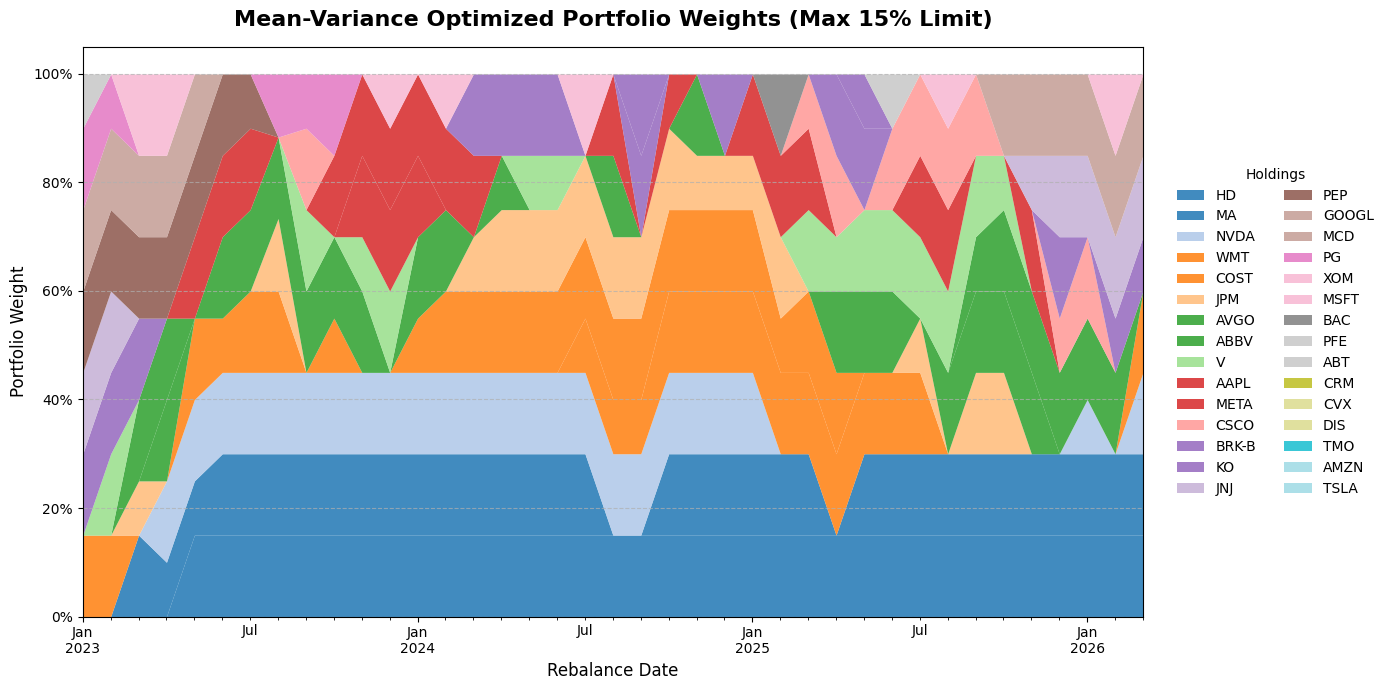

In [2]:
# Sort columns by most frequently held to make the chart clean
sorted_columns = optimized_weights.mean().sort_values(ascending=False).index
plot_data = optimized_weights[sorted_columns]

fig, ax = plt.subplots(figsize=(14, 7))

# Plot the new dynamic weights
plot_data.plot.area(ax=ax, colormap='tab20', alpha=0.85, linewidth=0)

ax.set_title('Mean-Variance Optimized Portfolio Weights (Max 15% Limit)', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Portfolio Weight', fontsize=12)
ax.set_xlabel('Rebalance Date', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title="Holdings", frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [3]:
# 1. Generate Equal-Weight "Dumb" Weights for baseline comparison
# (Top 10 equal-weight, as we did in Phase 1)
weights_equal = generate_target_weights(composite_scores, top_n=10)

# 2. Calculate Net Returns for both models (assuming 20 bps transaction costs)
print("Calculating Equal-Weight returns...")
_, net_equal = calculate_portfolio_performance(weights_equal, daily_returns, cost_bps=20)

print("Calculating Optimized MVO returns...")
_, net_optimized = calculate_portfolio_performance(optimized_weights, daily_returns, cost_bps=20)

# Rename series for clarity
net_equal.name = "Equal-Weight (Top 10)"
net_optimized.name = "MVO Optimized (Max 15%)"

# Align the series and the benchmark
import yfinance as yf
benchmark_data = yf.download('SPY', start=net_optimized.index[0], end='2026-03-26', auto_adjust=True, progress=False)
benchmark_returns = benchmark_data['Close'].pct_change().dropna()
if isinstance(benchmark_returns, pd.DataFrame):
    benchmark_returns = benchmark_returns.iloc[:, 0]
benchmark_returns.name = "S&P 500 (SPY)"

# Align all three tightly
comparison_df = pd.concat([net_equal, net_optimized, benchmark_returns], axis=1).dropna()
comparison_df.columns = ['Equal-Weight', 'Optimized', 'Benchmark']

2026-03-27 22:08:39,214 - INFO - Generating monthly target weights for top 10 stocks...
2026-03-27 22:08:39,226 - INFO - Calculating performance with 20 bps transaction cost...
2026-03-27 22:08:39,230 - INFO - Calculating performance with 20 bps transaction cost...


Calculating Equal-Weight returns...
Calculating Optimized MVO returns...


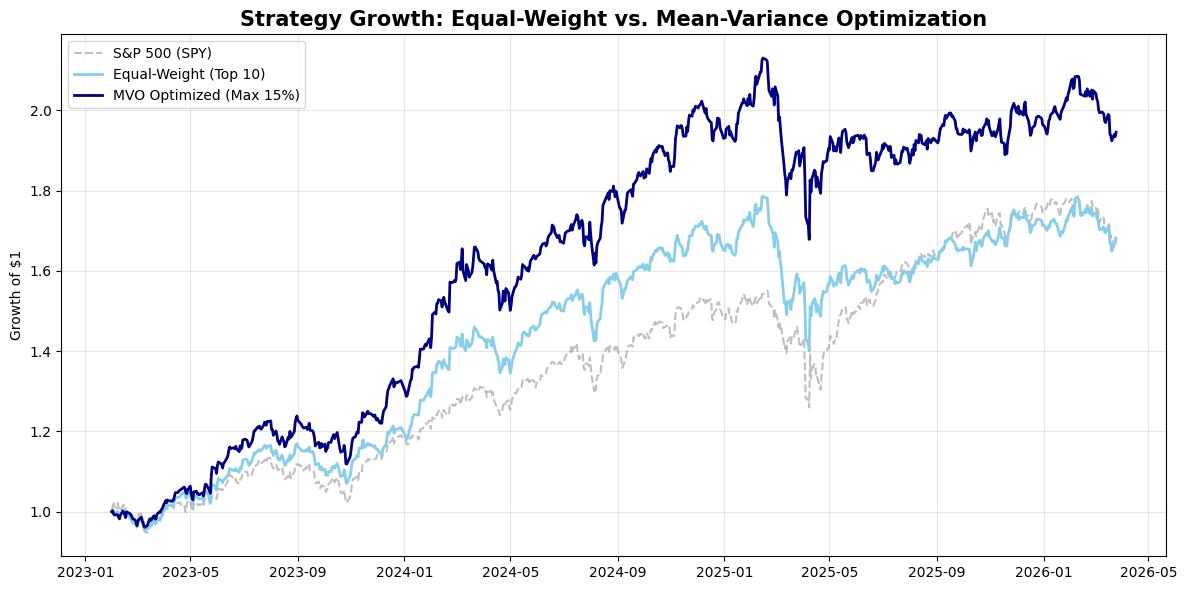


--- PERFORMANCE SUMMARY ---
Equal-Weight CAGR: 18.04%
Optimized CAGR:    23.68%
Equal-Weight Sharpe: 1.18
Optimized Sharpe:    1.36
Equal-Weight Max DD: -21.56%
Optimized Max DD:    -21.21%


In [4]:
# Helper to get base 1.0 cumulative returns
def get_cumulative(series):
    start_date = series.index[0] - pd.Timedelta(days=1)
    combined = pd.concat([pd.Series([0], index=[start_date]), series])
    return (1 + combined).cumprod()

cum_equal = get_cumulative(comparison_df['Equal-Weight'])
cum_optimized = get_cumulative(comparison_df['Optimized'])
cum_bench = get_cumulative(comparison_df['Benchmark'])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cum_bench, label='S&P 500 (SPY)', color='gray', alpha=0.5, linestyle='--')
ax.plot(cum_equal, label='Equal-Weight (Top 10)', color='skyblue', linewidth=2)
ax.plot(cum_optimized, label='MVO Optimized (Max 15%)', color='navy', linewidth=2)

ax.set_title("Strategy Growth: Equal-Weight vs. Mean-Variance Optimization", fontsize=15, fontweight='bold')
ax.set_ylabel("Growth of $1")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print the top-line stats using QuantStats
import quantstats as qs
print("\n--- PERFORMANCE SUMMARY ---")
print(f"Equal-Weight CAGR: {qs.stats.cagr(comparison_df['Equal-Weight']):.2%}")
print(f"Optimized CAGR:    {qs.stats.cagr(comparison_df['Optimized']):.2%}")
print(f"Equal-Weight Sharpe: {qs.stats.sharpe(comparison_df['Equal-Weight']):.2f}")
print(f"Optimized Sharpe:    {qs.stats.sharpe(comparison_df['Optimized']):.2f}")
print(f"Equal-Weight Max DD: {qs.stats.max_drawdown(comparison_df['Equal-Weight']):.2%}")
print(f"Optimized Max DD:    {qs.stats.max_drawdown(comparison_df['Optimized']):.2%}")


INSTITUTIONAL TEARSHEET: MVO OPTIMIZED PORTFOLIO



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2023-02-01   2023-02-01
End Period           2026-03-25   2026-03-25
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       100.0%

Cumulative Return    68.56%       94.51%
CAGR﹪               18.15%       23.68%

Sharpe               1.18         1.36
Prob. Sharpe Ratio   98.32%       99.3%
Sortino              1.75         2.13
Sortino/√2           1.24         1.5
Omega                1.24         1.27

Max Drawdown         -18.76%      -21.21%
Max DD Date          2025-04-08   2025-04-08
Max DD Period Start  2025-02-20   2025-02-18
Max DD Period End    2025-06-25   2026-03-25
Longest DD Days      126          401

Gain/Pain Ratio      0.24         0.27
Gain/Pain (1M)       1.87         1.79

Payoff Rat

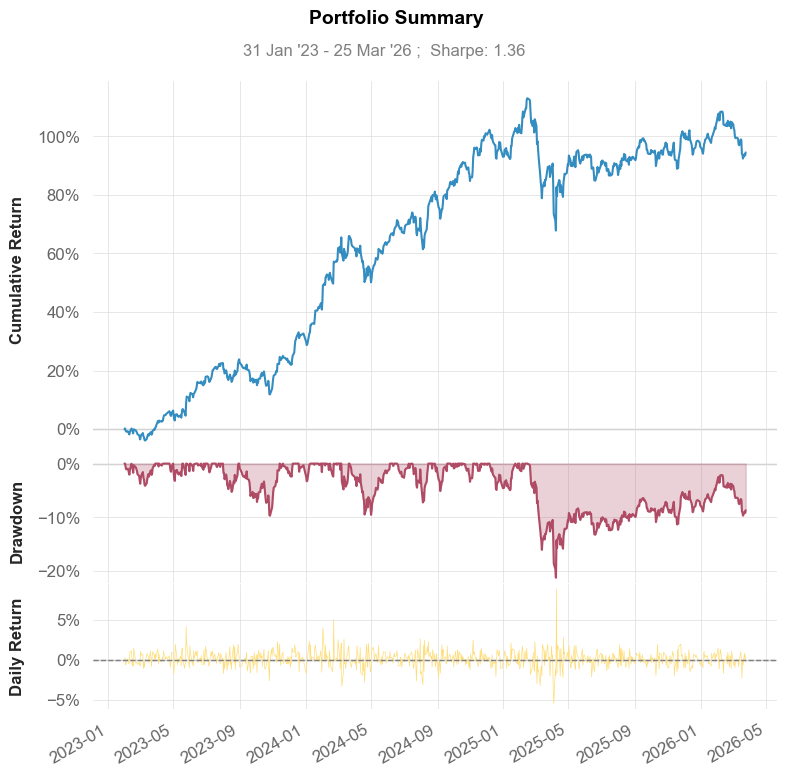

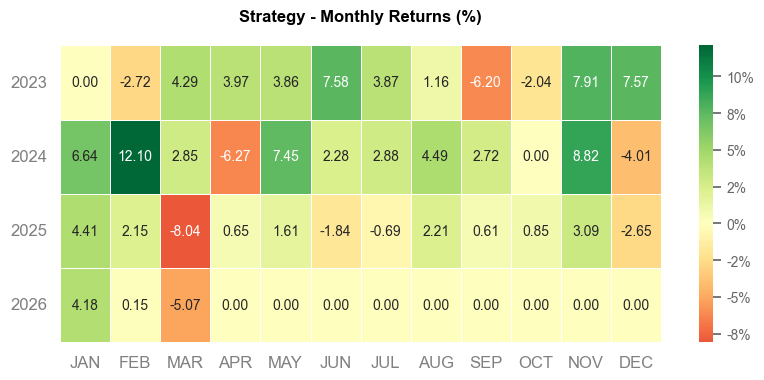

In [5]:
# Generate the full tearsheet for the Optimized portfolio
print("\n" + "="*50)
print("INSTITUTIONAL TEARSHEET: MVO OPTIMIZED PORTFOLIO")
print("="*50)
qs.reports.basic(comparison_df['Optimized'], benchmark=comparison_df['Benchmark'])

2026-03-27 22:08:41,549 - INFO - Starting Walk-Forward Optimization (Lookback: 12M)...
2026-03-27 22:08:41,572 - INFO - Generated 66 hyperparameter combinations.
2026-03-27 22:08:48,866 - INFO - Generating optimized weights via SciPy (Max Weight: 15.0%)...



Running SciPy MVO on Out-Of-Sample Walk-Forward Signals...


2026-03-27 22:08:49,153 - INFO - Calculating performance with 20 bps transaction cost...


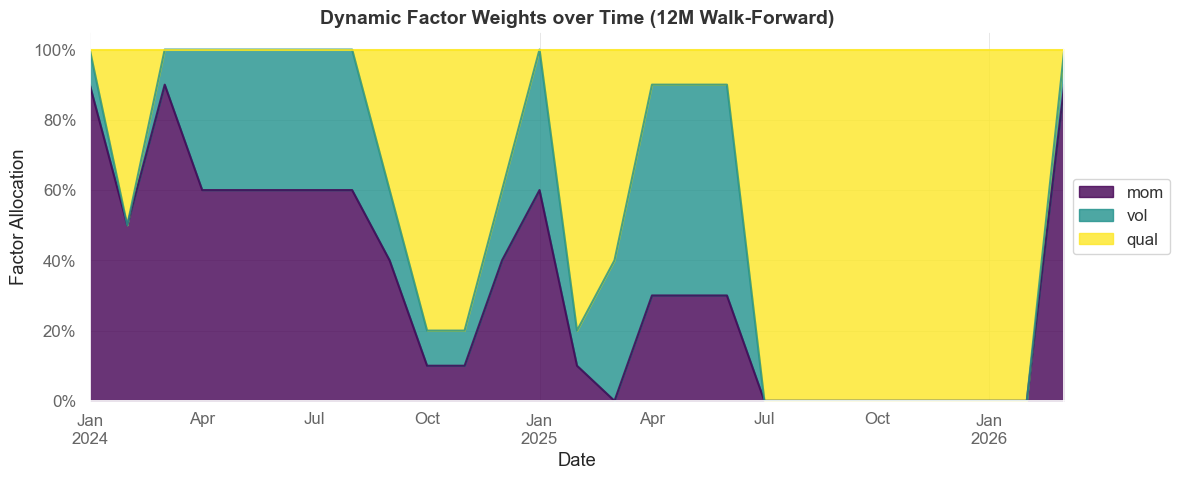


--- OUT OF SAMPLE PERFORMANCE ---
Strategy CAGR:   10.99%
Benchmark CAGR:  15.96%
Strategy Sharpe: 0.67
Benchmark Sharpe:0.99


In [6]:
# Import the new module
from hyperopt import walk_forward_optimization, walk_forward_regression, walk_forward_risk_parity
import quantstats as qs

# 1. Run Walk-Forward Validation (12 Month Lookback)
# Note: Because our dataset starts in 2022, we use 12 months instead of 24 
# so we still have enough out-of-sample years to test.
dynamic_scores, optimal_factor_weights = walk_forward_optimization(
    z_mom, z_vol, z_roe, prices, lookback_months=12
)

# 2. Feed the dynamic Out-of-Sample scores into our SciPy Optimizer
print("\nRunning SciPy MVO on Out-Of-Sample Walk-Forward Signals...")
wf_optimized_weights = generate_optimized_weights(
    dynamic_scores, daily_returns, top_n=20, max_weight=0.15
)

# 3. Calculate Final Net Returns (20 bps cost)
_, net_wf_optimized = calculate_portfolio_performance(wf_optimized_weights, daily_returns, cost_bps=20)
net_wf_optimized.name = "Walk-Forward SciPy MVO"

# 4. Visualize How Factor Preferences Changed Over Time
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12, 5))
optimal_factor_weights.plot.area(ax=ax, colormap='viridis', alpha=0.8)
ax.set_title("Dynamic Factor Weights over Time (12M Walk-Forward)", fontsize=14, fontweight='bold')
ax.set_ylabel("Factor Allocation")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Print Final OOS Stats
benchmark_returns = yf.download('SPY', start=net_wf_optimized.index[0], end=net_wf_optimized.index[-1], auto_adjust=True, progress=False)['Close'].pct_change().dropna().iloc[:, 0]
benchmark_returns.name = "S&P 500"

wf_comp = pd.concat([net_wf_optimized, benchmark_returns], axis=1).dropna()
print("\n--- OUT OF SAMPLE PERFORMANCE ---")
print(f"Strategy CAGR:   {qs.stats.cagr(wf_comp.iloc[:, 0]):.2%}")
print(f"Benchmark CAGR:  {qs.stats.cagr(wf_comp.iloc[:, 1]):.2%}")
print(f"Strategy Sharpe: {qs.stats.sharpe(wf_comp.iloc[:, 0]):.2f}")
print(f"Benchmark Sharpe:{qs.stats.sharpe(wf_comp.iloc[:, 1]):.2f}")

2026-03-27 22:08:49,606 - INFO - Starting Risk Parity Walk-Forward (Lookback: 12M)...


Generating Risk Parity Walk-Forward Scores...


2026-03-27 22:08:49,905 - INFO - Generating optimized weights via SciPy (Max Weight: 15.0%)...


Running SciPy MVO on Risk Parity Signals...


2026-03-27 22:08:50,167 - INFO - Calculating performance with 20 bps transaction cost...


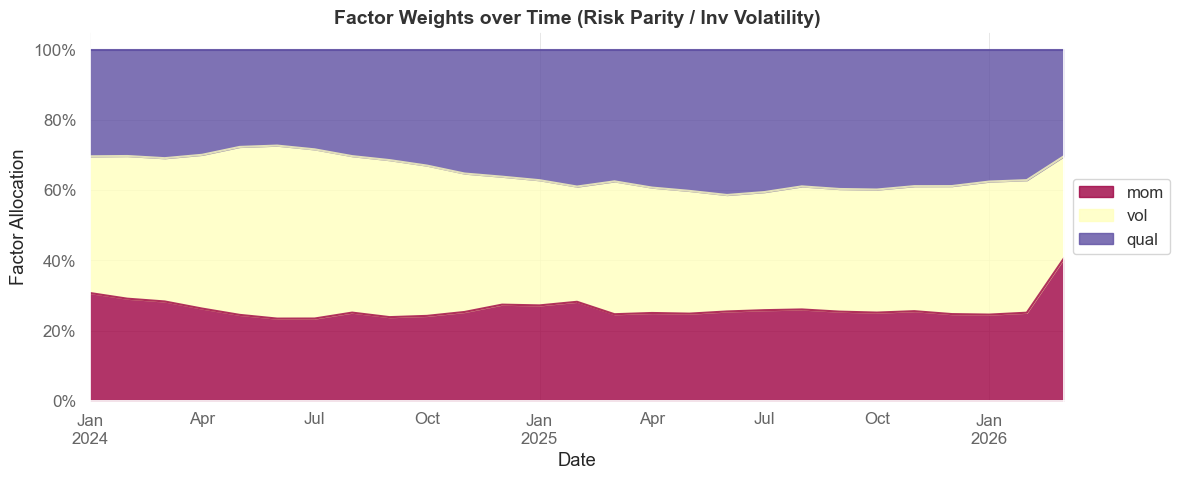


--- OUT OF SAMPLE: RISK PARITY ---
Strategy CAGR:   11.67%
Benchmark CAGR:  15.96%
Strategy Sharpe: 0.82
Benchmark Sharpe:0.99


In [7]:
# --- METHOD B: RISK PARITY WALK-FORWARD ---
from hyperopt import walk_forward_risk_parity
from optimizer import generate_optimized_weights
from backtest import calculate_portfolio_performance
import quantstats as qs
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf
import pandas as pd

# 1. Generate Walk-Forward Scores (12-Month Lookback)
print("Generating Risk Parity Walk-Forward Scores...")
rp_scores, rp_weights = walk_forward_risk_parity(z_mom, z_vol, z_roe, prices, lookback_months=12)

# 2. Run through SciPy MVO (Max 15% Weight)
print("Running SciPy MVO on Risk Parity Signals...")
rp_optimized_weights = generate_optimized_weights(rp_scores, daily_returns, top_n=20, max_weight=0.15)

# 3. Calculate Net Returns (20 bps friction)
_, net_rp = calculate_portfolio_performance(rp_optimized_weights, daily_returns, cost_bps=20)
net_rp.name = "Risk Parity MVO"

# 4. Visualize Weight Shifts
fig, ax = plt.subplots(figsize=(12, 5))
rp_weights.plot.area(ax=ax, colormap='Spectral', alpha=0.8)
ax.set_title("Factor Weights over Time (Risk Parity / Inv Volatility)", fontsize=14, fontweight='bold')
ax.set_ylabel("Factor Allocation")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# 5. Print Performance against S&P 500
benchmark = yf.download('SPY', start=net_rp.index[0], end=net_rp.index[-1], auto_adjust=True, progress=False)['Close'].pct_change().dropna()
if isinstance(benchmark, pd.DataFrame): benchmark = benchmark.iloc[:, 0]
benchmark.name = "S&P 500"

comp_rp = pd.concat([net_rp, benchmark], axis=1).dropna()
print("\n--- OUT OF SAMPLE: RISK PARITY ---")
print(f"Strategy CAGR:   {qs.stats.cagr(comp_rp.iloc[:, 0]):.2%}")
print(f"Benchmark CAGR:  {qs.stats.cagr(comp_rp.iloc[:, 1]):.2%}")
print(f"Strategy Sharpe: {qs.stats.sharpe(comp_rp.iloc[:, 0]):.2f}")
print(f"Benchmark Sharpe:{qs.stats.sharpe(comp_rp.iloc[:, 1]):.2f}")

2026-03-27 22:08:50,357 - INFO - Starting ML Regression Walk-Forward (Lookback: 12M)...


Generating ML Ridge Regression Walk-Forward Scores...
Running SciPy MVO on ML Regression Signals...


2026-03-27 22:08:50,670 - INFO - Generating optimized weights via SciPy (Max Weight: 15.0%)...
2026-03-27 22:08:50,927 - INFO - Calculating performance with 20 bps transaction cost...


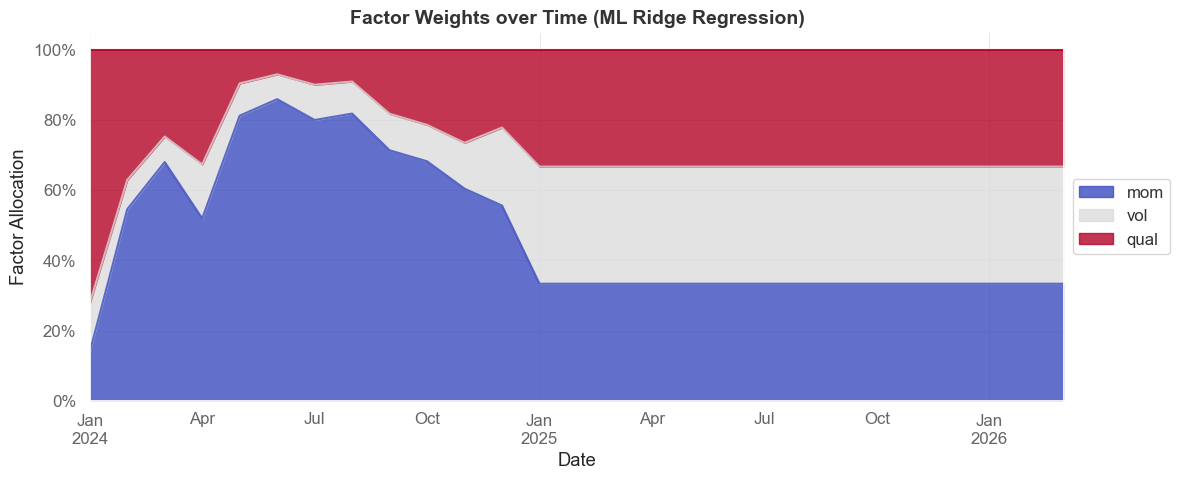


--- OUT OF SAMPLE: ML REGRESSION ---
Strategy CAGR:   19.35%
Benchmark CAGR:  15.96%
Strategy Sharpe: 1.01
Benchmark Sharpe:0.99


In [8]:
# --- METHOD C: MACHINE LEARNING (RIDGE REGRESSION) WALK-FORWARD ---
from hyperopt import walk_forward_regression
from optimizer import generate_optimized_weights
from backtest import calculate_portfolio_performance
import quantstats as qs
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf
import pandas as pd

# 1. Generate ML Walk-Forward Scores (12-Month Lookback)
print("Generating ML Ridge Regression Walk-Forward Scores...")
ml_scores, ml_weights = walk_forward_regression(z_mom, z_vol, z_roe, prices, lookback_months=12)

# 2. Run through SciPy MVO (Max 15% Weight)
print("Running SciPy MVO on ML Regression Signals...")
ml_optimized_weights = generate_optimized_weights(ml_scores, daily_returns, top_n=20, max_weight=0.15)

# 3. Calculate Net Returns (20 bps friction)
_, net_ml = calculate_portfolio_performance(ml_optimized_weights, daily_returns, cost_bps=20)
net_ml.name = "ML Regression MVO"

# 4. Visualize Weight Shifts
fig, ax = plt.subplots(figsize=(12, 5))
ml_weights.plot.area(ax=ax, colormap='coolwarm', alpha=0.8)
ax.set_title("Factor Weights over Time (ML Ridge Regression)", fontsize=14, fontweight='bold')
ax.set_ylabel("Factor Allocation")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# 5. Print Performance against S&P 500
benchmark = yf.download('SPY', start=net_ml.index[0], end=net_ml.index[-1], auto_adjust=True, progress=False)['Close'].pct_change().dropna()
if isinstance(benchmark, pd.DataFrame): benchmark = benchmark.iloc[:, 0]
benchmark.name = "S&P 500"

comp_ml = pd.concat([net_ml, benchmark], axis=1).dropna()
print("\n--- OUT OF SAMPLE: ML REGRESSION ---")
print(f"Strategy CAGR:   {qs.stats.cagr(comp_ml.iloc[:, 0]):.2%}")
print(f"Benchmark CAGR:  {qs.stats.cagr(comp_ml.iloc[:, 1]):.2%}")
print(f"Strategy Sharpe: {qs.stats.sharpe(comp_ml.iloc[:, 0]):.2f}")
print(f"Benchmark Sharpe:{qs.stats.sharpe(comp_ml.iloc[:, 1]):.2f}")